# PR Classification Analysis Notebook

In [1]:
# ============================================================================
# Setup and Imports
# ============================================================================
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

# Add notebooks directory to path
sys.path.append(str(Path.cwd()))

from analysis_helper import (
    load_local_data,
    load_prs,
    load_labels,
    get_agents,
    validate_data,
    print_summary_stats,
    normalize_agent_name,
    get_agent_color,
    mannUandCliffdelta,
    FIG_DIR,
    COLOR_MAP,
    FLOW_ORDER,
)

# Matplotlib settings
FONT_SCALE = 1.4
_BASE_FONT = 10

sns.set_style("whitegrid")
sns.set_context("talk", font_scale=FONT_SCALE)

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": _BASE_FONT * FONT_SCALE,
        "axes.titlesize": _BASE_FONT * FONT_SCALE * 1.2,
        "axes.labelsize": _BASE_FONT * FONT_SCALE,
        "xtick.labelsize": _BASE_FONT * FONT_SCALE * 0.9,
        "ytick.labelsize": _BASE_FONT * FONT_SCALE * 0.9,
        "legend.fontsize": _BASE_FONT * FONT_SCALE * 0.9,
    }
)

SECONDS_TO_HOUR = 3600

print("✓ Imports complete")

✓ Imports complete


In [2]:
# ============================================================================
# Load Data
# ============================================================================
# Load all data (optionally filter by stars)
# data = load_local_data(stars_range=(500, None))  # Repos with 500+ stars
data = load_local_data()  # All repos

# Validate and print summary
validate_data(data)
print_summary_stats(data)

agents = get_agents(data)
print(f"\nAgents to analyze: {agents}")

# Verify ID types
print(f"\nID types:")
print(f"  PRs: {data.pr_df['id'].dtype}")
print(f"  Classifications: {data.lbl_df['id'].dtype}")

✓ Data validated
  PRs: 209934 across 7 agents
  Classifications: 209934
  Agents: Human, claude-code, codex, copilot, cursor, devin, jules

DATASET SUMMARY

Human:
  Total PRs: 154285
  Classified: 154285 (100.0%)
  Merged: 113396 (73.5%)
  Closed (not merged): 30416
  Open: 10473
  Top types: feat(47092), fix(43546), chore(15240), refactor(13327), docs(11229)

Claude Code:
  Total PRs: 3290
  Classified: 3290 (100.0%)
  Merged: 2025 (61.6%)
  Closed (not merged): 915
  Open: 350
  Top types: fix(1223), feat(1216), refactor(243), docs(178), chore(161)

OpenAI Codex:
  Total PRs: 7238
  Classified: 7238 (100.0%)
  Merged: 4654 (64.3%)
  Closed (not merged): 2007
  Open: 577
  Top types: feat(2574), fix(1996), refactor(686), docs(637), chore(466)

GitHub Copilot:
  Total PRs: 35775
  Classified: 35775 (100.0%)
  Merged: 21437 (59.9%)
  Closed (not merged): 11478
  Open: 2860
  Top types: fix(11345), feat(9488), docs(4050), refactor(3655), chore(1944)

Cursor:
  Total PRs: 4217
  Classif

In [3]:
# ============================================================================
# Analysis Functions
# ============================================================================
def analyze_agent(agent: str, data) -> pd.DataFrame:
    """Analyze PR statistics for one agent."""
    prs = load_prs(agent, data)
    labels = load_labels(agent, data)

    if prs.empty or labels.empty:
        return pd.DataFrame()

    # Merge PRs with classifications
    df = prs.merge(labels[["id", "type"]], on="id", how="inner")

    # Determine status
    df["status"] = np.select(
        [df["state"] == "open", pd.notna(df["merged_at"])],
        ["open", "merged"],
        default="closed",
    )

    # Calculate turnaround time
    df["end_at"] = df["merged_at"].fillna(df["closed_at"])
    df["turnaround_hours"] = (
        df["end_at"] - df["created_at"]
    ).dt.total_seconds() / SECONDS_TO_HOUR

    # Summarize by type
    def summarise(group: pd.DataFrame) -> pd.Series:
        stats = {
            "total": len(group),
            "open_pct": 100 * (group["status"] == "open").mean(),
            "closed_pct": 100 * (group["status"] == "closed").mean(),
            "merged_pct": 100 * (group["status"] == "merged").mean(),
        }

        non_open = group[group["status"] != "open"]
        stats["median_hours"] = non_open["turnaround_hours"].median()
        stats["median_hours_closed"] = group[group["status"] == "closed"][
            "turnaround_hours"
        ].median()
        stats["median_hours_merged"] = group[group["status"] == "merged"][
            "turnaround_hours"
        ].median()

        return pd.Series(stats)

    out = df.groupby("type").apply(summarise).sort_values("total", ascending=False)
    return out


# Test the analysis
for agent in agents[:7]:
    print(f"\n{'='*60}")
    print(f"Agent: {normalize_agent_name(agent)}")
    print("=" * 60)
    summary = analyze_agent(agent, data)
    if not summary.empty:
        print(summary[["total", "merged_pct"]].to_string(float_format="%.2f"))


Agent: Human


C:\Users\jaker\AppData\Local\Temp\ipykernel_18256\1747584020.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = df.groupby("type").apply(summarise).sort_values("total", ascending=False)
C:\Users\jaker\AppData\Local\Temp\ipykernel_18256\1747584020.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = df.groupby("type").apply(summarise).sort_values("total", ascending=False)


            total  merged_pct
type                         
feat     47092.00       67.45
fix      43546.00       76.59
chore    15240.00       77.87
refactor 13327.00       78.69
docs     11229.00       75.52
build     6908.00       76.94
test      5201.00       67.93
perf      4314.00       69.66
ci        2898.00       74.98
style     2187.00       84.22
revert    1538.00       80.23
other      805.00       42.48

Agent: Claude Code
           total  merged_pct
type                        
fix      1223.00       58.63
feat     1216.00       58.96
refactor  243.00       75.31
docs      178.00       69.66
chore     161.00       75.78
test       85.00       64.71
perf       73.00       45.21
build      59.00       59.32
ci         29.00       65.52
style      15.00       93.33
revert      7.00       71.43
other       1.00      100.00

Agent: OpenAI Codex


C:\Users\jaker\AppData\Local\Temp\ipykernel_18256\1747584020.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = df.groupby("type").apply(summarise).sort_values("total", ascending=False)


           total  merged_pct
type                        
feat     2574.00       59.29
fix      1996.00       62.93
refactor  686.00       76.09
docs      637.00       71.74
chore     466.00       66.74
test      255.00       69.02
perf      194.00       54.12
ci        174.00       72.99
build     163.00       74.85
style      57.00       70.18
other      22.00       13.64
revert     14.00       64.29

Agent: GitHub Copilot


C:\Users\jaker\AppData\Local\Temp\ipykernel_18256\1747584020.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = df.groupby("type").apply(summarise).sort_values("total", ascending=False)
C:\Users\jaker\AppData\Local\Temp\ipykernel_18256\1747584020.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = df.groupby("type").apply(summarise).sort_values("total", ascending=False)


            total  merged_pct
type                         
fix      11347.00       60.77
feat      9488.00       57.86
docs      4050.00       58.69
refactor  3655.00       64.90
chore     1944.00       49.95
build     1795.00       63.68
test      1211.00       63.17
style      706.00       73.80
perf       679.00       56.11
ci         623.00       69.02
revert     207.00       36.23
other       72.00       22.22

Agent: Cursor
           total  merged_pct
type                        
feat     1406.00       57.61
fix      1090.00       62.84
docs      489.00       65.44
refactor  393.00       68.96
chore     303.00       50.83
style     128.00       67.97
build     123.00       47.15
perf      100.00       54.00
test       97.00       47.42
ci         51.00       66.67
other      19.00       26.32
revert     18.00       61.11

Agent: Devin
           total  merged_pct
type                        
feat     1442.00       68.93
fix      1219.00       57.51
docs      495.00       69.90


C:\Users\jaker\AppData\Local\Temp\ipykernel_18256\1747584020.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = df.groupby("type").apply(summarise).sort_values("total", ascending=False)
C:\Users\jaker\AppData\Local\Temp\ipykernel_18256\1747584020.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = df.groupby("type").apply(summarise).sort_values("total", ascending=False)


In [4]:
# ============================================================================
# Gather Merged Percentage Data
# ============================================================================
def gather_merged_pct(agents, data, min_instances: int = 5) -> pd.DataFrame:
    """Gather merged percentage by type for all agents."""
    rows = []

    for agent in agents:
        summary = analyze_agent(agent, data)
        summary = summary[
            (summary.index != "other") & (summary["total"] >= min_instances)
        ]

        if summary.empty:
            continue

        tmp = summary.reset_index()[["type", "merged_pct"]].copy()
        tmp["agent"] = agent
        rows.append(tmp)

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


merged_df = gather_merged_pct(agents, data)
print(f"\n✓ Gathered merged percentages: {len(merged_df)} records")
print(merged_df.head(10))

C:\Users\jaker\AppData\Local\Temp\ipykernel_18256\1747584020.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = df.groupby("type").apply(summarise).sort_values("total", ascending=False)
C:\Users\jaker\AppData\Local\Temp\ipykernel_18256\1747584020.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = df.groupby("type").apply(summarise).sort_values("total", ascending=False)
C:\Users\jaker\AppData\Local\Tem


✓ Gathered merged percentages: 76 records
       type  merged_pct  agent
0      feat   67.453071  Human
1       fix   76.592569  Human
2     chore   77.867454  Human
3  refactor   78.689878  Human
4      docs   75.518746  Human
5     build   76.939780  Human
6      test   67.929244  Human
7      perf   69.656931  Human
8        ci   74.982747  Human
9     style   84.224966  Human


C:\Users\jaker\AppData\Local\Temp\ipykernel_18256\1747584020.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = df.groupby("type").apply(summarise).sort_values("total", ascending=False)


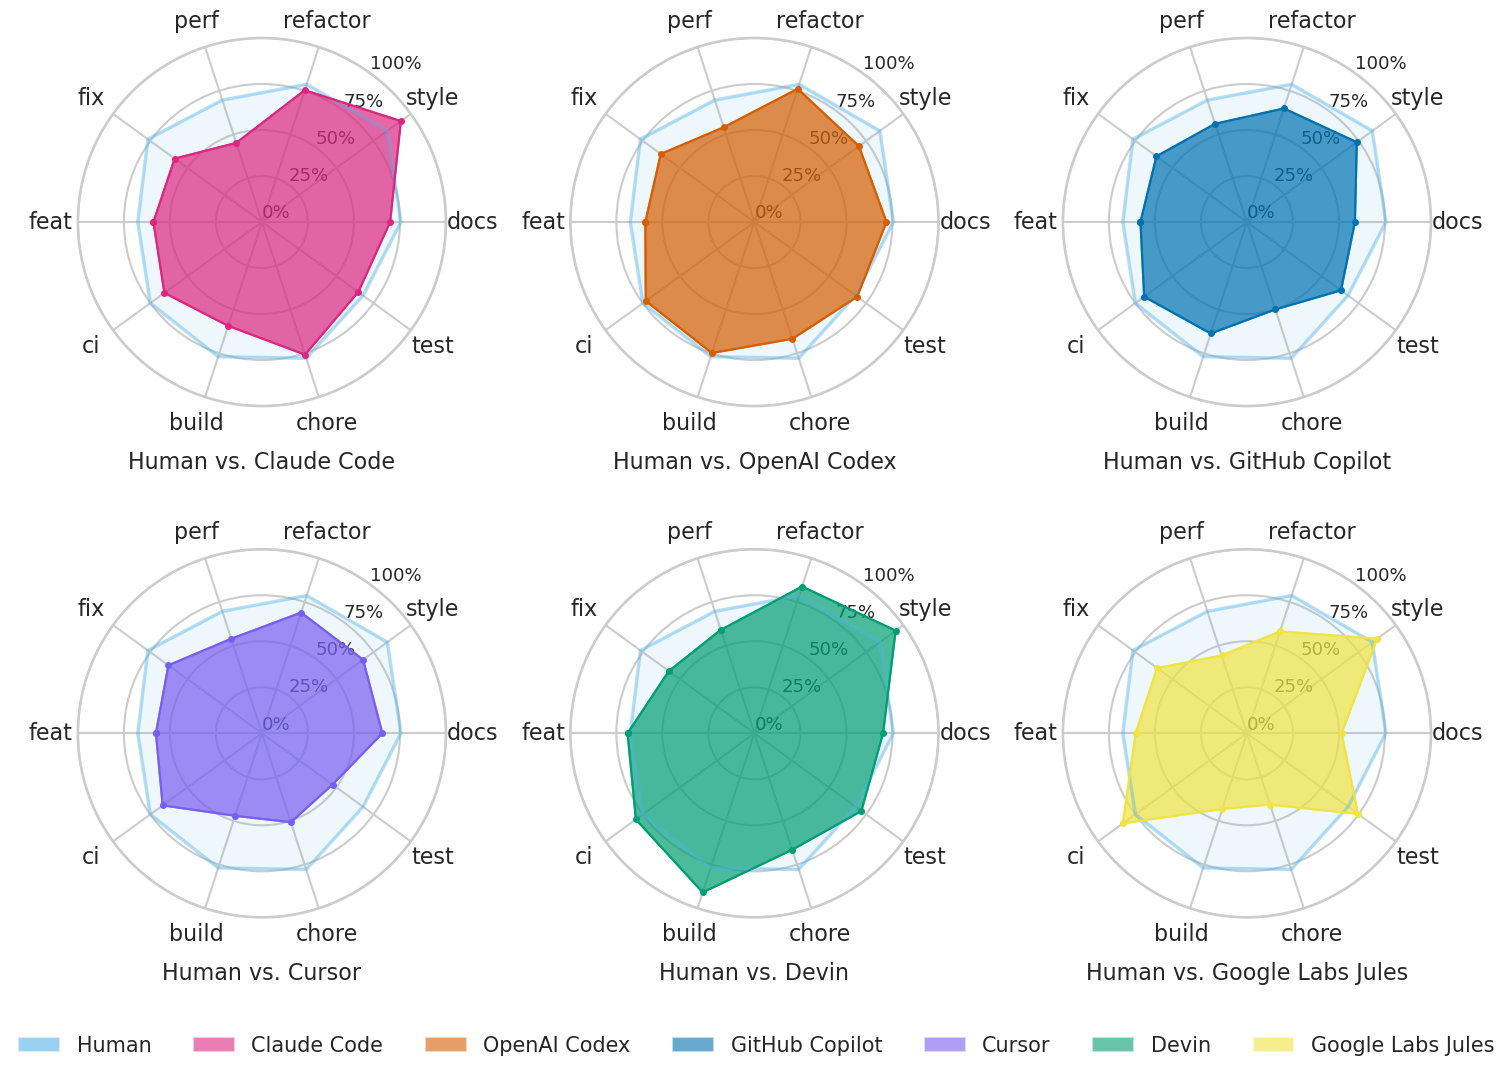

✓ Saved: figures\pr_merge_radar.pdf
✓ Saved: figures\pr_merge_radar.png


In [5]:
# ============================================================================
# Radar Plot (Multi-panel with Human baseline)
# ============================================================================
def plot_merged_pct_radar(
    df: pd.DataFrame, out_fp: Path | str, *, font_size: int = 15
) -> None:
    """Create radar plot comparing agents to Human baseline."""
    if df.empty:
        print("❗ No data to plot")
        return

    plt.rcParams.update({"font.size": font_size})

    # Get categories and agents
    cats = [c for c in FLOW_ORDER if c in df["type"].unique()]
    if not cats:
        print("❗ No recognized type categories found")
        return

    # Set up polar coordinates
    theta = np.linspace(0, 2 * np.pi, len(cats), endpoint=False)[::-1]
    theta = np.concatenate([theta[4:], theta[:4]])  # Move 'feat' to top
    theta = np.r_[theta, theta[0]]  # Close the loop

    # Check for Human baseline
    have_human = "Human" in df["agent"].unique()
    if have_human:
        human_s = df[df["agent"] == "Human"].set_index("type")["merged_pct"]

    # Get non-human agents (max 5)
    all_agents = df["agent"].unique()
    non_human = [a for a in all_agents if a != "Human"][:6]

    # Create figure with subplots
    fig = plt.figure(figsize=(15, 11))
    gs = fig.add_gridspec(nrows=2, ncols=6)

    slots = [
        (0, slice(0, 2)),
        (0, slice(2, 4)),
        (0, slice(4, 6)),
        (1, slice(0, 2)),
        (1, slice(2, 4)),
        (1, slice(4, 6)),
    ]

    for agent, (r, csl) in zip(non_human, slots):
        ax = fig.add_subplot(gs[r, csl], polar=True)

        # Plot human baseline if available
        if have_human:
            vals = [human_s.get(c, 0) for c in cats] + [human_s.get(cats[0], 0)]
            ax.plot(
                theta,
                vals,
                lw=2.5,
                color=COLOR_MAP.get("Human"),
                label="Human",
                alpha=0.4,
            )
            ax.fill(theta, vals, alpha=0.1, color=COLOR_MAP.get("Human"))

        # Plot agent
        agent_s = df[df["agent"] == agent].set_index("type")["merged_pct"]
        vals = [agent_s.get(c, 0) for c in cats] + [agent_s.get(cats[0], 0)]
        ax.plot(
            theta,
            vals,
            lw=1.5,
            color=get_agent_color(agent),
            label=normalize_agent_name(agent),
            marker="o",
            markersize=4,
        )
        ax.fill(theta, vals, alpha=0.7, color=get_agent_color(agent))

        # Styling
        ax.set_xticks(theta[:-1])
        ax.set_xticklabels(cats, fontsize=font_size + 1)
        ax.set_ylim(0, 100)
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.set_yticklabels(
            [f"{y}%" for y in [0, 25, 50, 75, 100]], fontsize=font_size - 2
        )
        ax.set_rlabel_position(54)
        # for label in ax.get_yticklabels():
        #     label.set_ha("right")

        # Subtitle
        subtitle = f"{'Human vs. ' if have_human else ''}{normalize_agent_name(agent)}"
        ax.text(
            0.5,
            -0.12,
            subtitle,
            ha="center",
            va="top",
            fontsize=font_size + 1,
            transform=ax.transAxes,
        )

    # Legend
    legend_handles = []
    legend_labels = []

    if have_human:
        legend_handles.append(
            Patch(facecolor=COLOR_MAP.get("Human"), alpha=0.6, label="Human")
        )
        legend_labels.append("Human")

    for a in non_human:
        legend_handles.append(
            Patch(
                facecolor=get_agent_color(a), alpha=0.6, label=normalize_agent_name(a)
            )
        )
        legend_labels.append(normalize_agent_name(a))

    fig.legend(
        handles=legend_handles,
        labels=legend_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0),
        ncol=len(legend_labels),
        fontsize=font_size,
        frameon=False,
    )

    fig.tight_layout(rect=[0, 0.05, 1, 1])

    # Save
    out_fp = Path(out_fp)
    out_fp.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_fp.with_suffix(".pdf"), dpi=300)
    fig.savefig(out_fp.with_suffix(".png"), dpi=300)
    plt.show()
    plt.close(fig)

    print(f"✓ Saved: {out_fp.with_suffix('.pdf').relative_to(out_fp.parents[1])}")
    print(f"✓ Saved: {out_fp.with_suffix('.png').relative_to(out_fp.parents[1])}")


# Generate the plot
plot_merged_pct_radar(merged_df, FIG_DIR / "pr_merge_radar.pdf")

C:\Users\jaker\AppData\Local\Temp\ipykernel_18256\2971519334.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


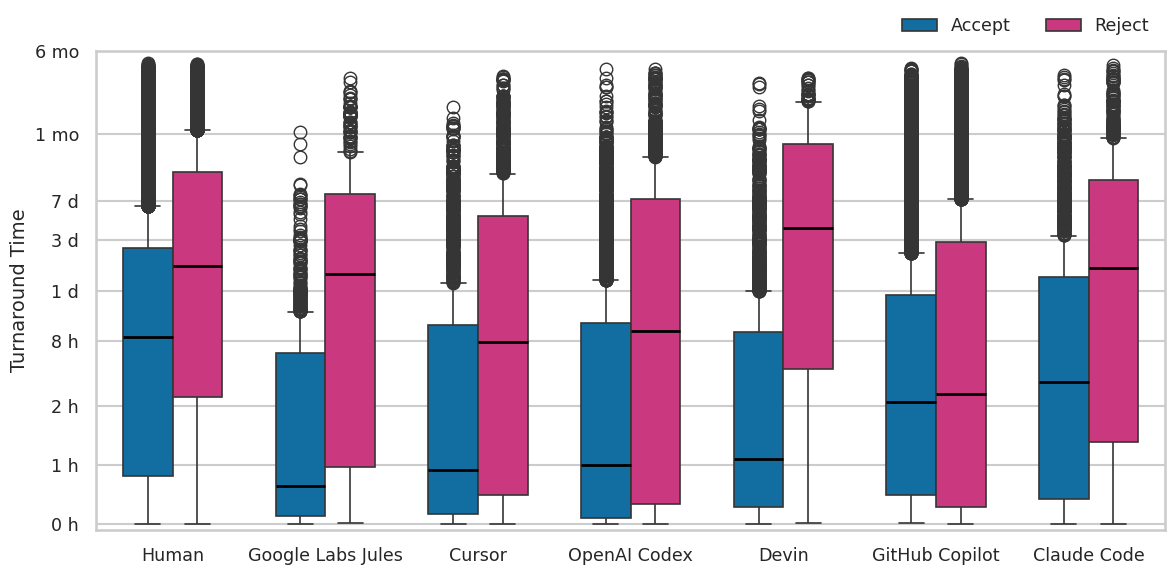

✓ Saved: figures\turnaround_distribution.pdf
✓ Saved: figures\turnaround_distribution.png


In [6]:
# ============================================================================
# Turnaround Time Distribution
# ============================================================================
def gather_turnaround_distribution(agents, data) -> pd.DataFrame:
    """Gather turnaround time distribution for Accept/Reject status."""
    frames = []

    for agent in agents:
        prs = load_prs(agent, data)
        labels = load_labels(agent, data)

        if prs.empty or labels.empty:
            continue

        df = prs.merge(labels[["id"]], on="id", how="inner")

        # Status
        df["status"] = np.select(
            [df["state"] == "open", pd.notna(df["merged_at"])],
            ["open", "merged"],
            default="closed",
        )

        # Turnaround
        df["end_at"] = df["merged_at"].fillna(df["closed_at"])
        df["turnaround_hours"] = (
            df["end_at"] - df["created_at"]
        ).dt.total_seconds() / SECONDS_TO_HOUR

        # Map to Accept/Reject
        status_map = {"closed": "Reject", "merged": "Accept"}
        df = df[df["status"].isin(status_map)]
        if df.empty:
            continue

        df["status"] = df["status"].map(status_map)
        df["agent"] = agent
        frames.append(df[["agent", "status", "turnaround_hours"]])

    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def plot_turnaround_box(
    df: pd.DataFrame,
    out_fp: Path,
    *,
    log_scale: bool = True,
) -> None:
    """Plot turnaround time as box plots."""
    if df.empty:
        print("❗ No data to plot")
        return

    # Order agents by median Accept time
    accept_medians = (
        df[df["status"] == "Accept"]
        .groupby("agent")["turnaround_hours"]
        .median()
        .sort_values()
    )

    ordered_agents = ["Human"] + [
        a for a in accept_medians.index if a != "Human" and a in df["agent"].unique()
    ]

    # Create plot
    fig, ax = plt.subplots(figsize=(12, 6))

    palette = {"Reject": "#DC267F", "Accept": "#0072B2"}

    sns.boxplot(
        data=df,
        x="agent",
        y="turnaround_hours",
        order=ordered_agents,
        hue="status",
        hue_order=["Accept", "Reject"],
        palette=palette,
        showcaps=True,
        showfliers=True,
        width=0.65,
        saturation=0.8,
        linewidth=1.2,
        ax=ax,
        medianprops={"linewidth": 2, "color": "#000000"},
    )

    ax.set_xlabel("")
    ax.set_ylabel("Turnaround Time")

    if log_scale:
        ax.set_yscale("symlog")

    ax.set_ylim(-0.1)

    hours_yticks = [0, 1, 2, 8, 24, 24 * 3, 24 * 7, 24 * 30, 24 * 180]
    ax.set_yticks(hours_yticks)
    ax.set_yticklabels(
        [
            f"{h} h" if h < 24 else f"{h//24} d" if h < 24 * 30 else f"{h//(24*30)} mo"
            for h in hours_yticks
        ]
    )

    # Clean legend
    handles, labels = ax.get_legend_handles_labels()
    unique = [
        (h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]
    ]
    ax.legend(
        *zip(*unique),
        frameon=False,
        ncol=2,
        loc="lower right",
        bbox_to_anchor=(1, 1),
    )

    # Normalize agent names on x-axis
    ax.set_xticklabels(
        [normalize_agent_name(lbl.get_text()) for lbl in ax.get_xticklabels()]
    )

    fig.tight_layout()

    # Save
    out_fp = Path(out_fp)
    out_fp.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_fp.with_suffix(".pdf"), dpi=300)
    fig.savefig(out_fp.with_suffix(".png"), dpi=300)
    plt.show()
    plt.close(fig)

    print(f"✓ Saved: {out_fp.with_suffix('.pdf').relative_to(out_fp.parents[1])}")
    print(f"✓ Saved: {out_fp.with_suffix('.png').relative_to(out_fp.parents[1])}")


# Generate turnaround plot
dist_df = gather_turnaround_distribution(agents, data)

# Remove negative values (timestamp artifacts)
dist_df = dist_df[dist_df["turnaround_hours"] >= 0]

plot_turnaround_box(dist_df, FIG_DIR / "turnaround_distribution.pdf")

In [7]:
# ============================================================================
# Statistical Comparison Table
# ============================================================================
def build_comparison_table(agents, dist_df, data, baseline="Human") -> pd.DataFrame:
    """Build statistical comparison table vs baseline."""

    # Helper to get stats for one agent
    def agent_stats(agent: str) -> dict:
        prs = load_prs(agent, data)
        labels = load_labels(agent, data)

        if prs.empty or labels.empty:
            return {}

        df = prs.merge(labels[["id"]], on="id", how="inner")
        df["status"] = np.select(
            [df["state"] == "open", pd.notna(df["merged_at"])],
            ["open", "merged"],
            default="closed",
        )
        df["end_at"] = df["merged_at"].fillna(df["closed_at"])
        df["turnaround_hours"] = (
            df["end_at"] - df["created_at"]
        ).dt.total_seconds() / SECONDS_TO_HOUR

        total = len(df)
        accept_cnt = (df["status"] == "merged").sum()
        reject_cnt = (df["status"] == "closed").sum()

        return {
            "total": total,
            "accept_rate": 100 * accept_cnt / total if total else np.nan,
            "reject_rate": 100 * reject_cnt / total if total else np.nan,
            "accept_median": df[df["status"] == "merged"]["turnaround_hours"].median(),
            "reject_median": df[df["status"] == "closed"]["turnaround_hours"].median(),
        }

    # Compute significance vs baseline
    sig_map = {"Accept": {}, "Reject": {}}
    cliff_map = {"Accept": {}, "Reject": {}}

    for status in ["Accept", "Reject"]:
        base_data = dist_df[
            (dist_df["agent"] == baseline) & (dist_df["status"] == status)
        ]["turnaround_hours"]

        if base_data.empty:
            continue

        for agent in agents:
            if agent == baseline:
                sig_map[status][agent] = ""
                cliff_map[status][agent] = ""
                continue

            sample = dist_df[
                (dist_df["agent"] == agent) & (dist_df["status"] == status)
            ]["turnaround_hours"]

            if sample.empty:
                sig_map[status][agent] = ""
                cliff_map[status][agent] = ""
                continue

            u, p, _, size = mannUandCliffdelta(sample.to_numpy(), base_data.to_numpy())
            sig_map[status][agent] = "*" if p < 0.05 else ""
            cliff_map[status][agent] = size

    # Build table
    rows = {}
    for agent in agents:
        stats = agent_stats(agent)
        rows[normalize_agent_name(agent)] = {
            ("Accept", "Rate"): round(stats.get("accept_rate", np.nan), 2),
            ("Accept", "Med"): round(stats.get("accept_median", np.nan), 2),
            ("Accept", "Sig"): sig_map["Accept"].get(agent, "-"),
            ("Accept", "Cliff"): cliff_map["Accept"].get(agent, "-"),
            ("Reject", "Rate"): round(stats.get("reject_rate", np.nan), 2),
            ("Reject", "Med"): round(stats.get("reject_median", np.nan), 2),
            ("Reject", "Sig"): sig_map["Reject"].get(agent, "-"),
            ("Reject", "Cliff"): cliff_map["Reject"].get(agent, "-"),
        }

    cols = pd.MultiIndex.from_product(
        [["Accept", "Reject"], ["Rate", "Med", "Sig", "Cliff"]],
        names=["Status", ""],
    )
    df = pd.DataFrame.from_dict(rows, orient="index", columns=cols)
    df.index.name = "Agent"
    return df


# Generate comparison table
table_df = build_comparison_table(agents, dist_df, data)
print("\n" + "=" * 60)
print("STATISTICAL COMPARISON TABLE")
print("=" * 60)
print(table_df)

# Save to CSV and LaTeX
table_csv = FIG_DIR / "comparison_table.csv"
table_tex = FIG_DIR / "comparison_table.tex"

csv_df = table_df.copy()
csv_df.columns = ["_".join(c).lower() for c in csv_df.columns]
csv_df.to_csv(table_csv, index=True)

latex = table_df.to_latex(
    escape=False,
    multirow=True,
    float_format="%.2f",
    caption="Turnaround statistics vs Human (* denotes p<0.05)",
    label="tab:turnaround_comparison",
)
table_tex.write_text(latex)

print(f"\n✓ Saved: {table_csv.relative_to(FIG_DIR.parent)}")
print(f"✓ Saved: {table_tex.relative_to(FIG_DIR.parent)}")

Cliff's delta: negligible, d=-0.11322944432740573
Mann-Whitney-U-test: u=101812289.0 p=2.1801064022091864e-18
Cliff's delta: medium, d=-0.3320447766423309
Mann-Whitney-U-test: u=176253455.0 p=0.0
Cliff's delta: small, d=-0.1552055354956771
Mann-Whitney-U-test: u=1026783727.0 p=2.7035295737360706e-285
Cliff's delta: small, d=-0.32827350728845506
Mann-Whitney-U-test: u=96546014.5 p=2.4053116537844347e-176
Cliff's delta: small, d=-0.30486791375789146
Mann-Whitney-U-test: u=101250074.0 p=2.389577824970994e-154
Cliff's delta: medium, d=-0.4089251756407001
Mann-Whitney-U-test: u=25268398.5 p=1.0480860054396993e-83
Cliff's delta: negligible, d=-0.030442095474627964
Mann-Whitney-U-test: u=13491708.5 p=0.11607675653736883
Cliff's delta: small, d=-0.17748180225077562
Mann-Whitney-U-test: u=25105275.5 p=1.3827476909584824e-40
Cliff's delta: small, d=-0.278994954118938
Mann-Whitney-U-test: u=125856783.5 p=0.0
Cliff's delta: small, d=-0.19250518046622742
Mann-Whitney-U-test: u=15559243.0 p=2.953614

In [8]:
# ============================================================================
# Summary
# ============================================================================
print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)
print(f"Figures saved to: {FIG_DIR.relative_to(FIG_DIR.parent.parent) if FIG_DIR.parent.parent.exists() else FIG_DIR.name}")
print("\nGenerated files:")
print(f"  - pr_merge_radar.pdf/png")
print(f"  - turnaround_distribution.pdf/png")
print(f"  - comparison_table.csv")
print(f"  - comparison_table.tex")
print("=" * 60)


ANALYSIS COMPLETE
Figures saved to: aidev-extended\figures

Generated files:
  - pr_merge_radar.pdf/png
  - turnaround_distribution.pdf/png
  - comparison_table.csv
  - comparison_table.tex


In [9]:
for agent in ["claude-code", "copilot", "cursor", "devin", "jules", "codegen"]:
    class_file = f"../data/processed/classified_prs/{agent}_pr_task_type.jsonl"
    try:
        df = pd.read_json(class_file, lines=True)
        total = len(df)
        regex = len(df[df["reason"] == "title provides conventional commit label"])
        llm = total - regex
        print(f"{agent}: {total} total, {regex} regex ({100*regex/total:.1f}%), {llm} LLM ({100*llm/total:.1f}%)")
    except:
        print(f"{agent}: file not found")

claude-code: 3290 total, 2171 regex (66.0%), 1119 LLM (34.0%)
copilot: 35775 total, 12131 regex (33.9%), 23644 LLM (66.1%)
cursor: 4217 total, 935 regex (22.2%), 3282 LLM (77.8%)
devin: 3853 total, 3144 regex (81.6%), 709 LLM (18.4%)
jules: 1276 total, 530 regex (41.5%), 746 LLM (58.5%)
codegen: 9 total, 2 regex (22.2%), 7 LLM (77.8%)


In [10]:
data = load_local_data()
agents = get_agents(data)

rows = []
for agent in agents:
    prs = load_prs(agent, data)
    labels = load_labels(agent, data)

    if prs.empty or labels.empty:
        continue

    # Calculate stats
    total = len(prs)
    classified = len(labels)
    merged = (prs["state"] == "closed") & prs["merged_at"].notna()

    # Get regex vs. LLM counts
    regex_count = len(
        labels[labels["reason"] == "title provides conventional commit label"]
    )
    llm_count = len(labels) - regex_count

    # Top 3 types
    top_types = labels["type"].value_counts().head(3)
    top_types_str = ", ".join([f"{typ}({cnt})" for typ, cnt in top_types.items()])

    rows.append(
        {
            "Agent": agent,
            "Total PRs": total,
            "Classified": classified,
            "Coverage (%)": f"{100*classified/total:.1f}",
            "Merged (%)": f"{100*merged.sum()/total:.1f}",
            "Regex (%)": (
                f"{100*regex_count/classified:.1f}" if classified > 0 else "0.0"
            ),
            "LLM (%)": f"{100*llm_count/classified:.1f}" if classified > 0 else "0.0",
            "Top Types": top_types_str,
        }
    )

df = pd.DataFrame(rows)

# Reorder to put Human first
if "Human" in df["Agent"].values:
    human_row = df[df["Agent"] == "Human"]
    other_rows = df[df["Agent"] != "Human"].sort_values("Total PRs", ascending=False)
    df = pd.concat([human_row, other_rows], ignore_index=True)

# print(df.to_markdown(index=False))
print("\n" + "=" * 80 + "\n")

# LaTeX version
latex = df.to_latex(
    index=False,
    escape=False,
    caption="Overview of collected PRs and classification coverage by agent",
    label="tab:agent_overview",
)
print(latex)



\begin{table}
\caption{Overview of collected PRs and classification coverage by agent}
\label{tab:agent_overview}
\begin{tabular}{lrrlllll}
\toprule
Agent & Total PRs & Classified & Coverage (%) & Merged (%) & Regex (%) & LLM (%) & Top Types \\
\midrule
Human & 154285 & 154285 & 100.0 & 73.5 & 40.3 & 59.7 & feat(47092), fix(43546), chore(15240) \\
copilot & 35775 & 35775 & 100.0 & 59.9 & 33.9 & 66.1 & fix(11345), feat(9488), docs(4050) \\
codex & 7238 & 7238 & 100.0 & 64.3 & 43.3 & 56.7 & feat(2574), fix(1996), refactor(686) \\
cursor & 4217 & 4217 & 100.0 & 60.1 & 22.2 & 77.8 & feat(1406), fix(1090), docs(489) \\
devin & 3853 & 3853 & 100.0 & 66.7 & 81.6 & 18.4 & feat(1442), fix(1219), docs(495) \\
claude-code & 3290 & 3290 & 100.0 & 61.6 & 66.0 & 34.0 & fix(1223), feat(1216), refactor(243) \\
jules & 1276 & 1276 & 100.0 & 59.1 & 41.5 & 58.5 & fix(373), feat(354), refactor(165) \\
\bottomrule
\end{tabular}
\end{table}



In [11]:
data = load_local_data()
agents = get_agents(data)

# Collect type distributions
type_dists = {}
for agent in agents:
    labels = load_labels(agent, data)
    if labels.empty:
        continue

    total = len(labels)
    dist = {}
    for typ in FLOW_ORDER:
        count = len(labels[labels["type"] == typ])
        dist[typ] = f"{100*count/total:.1f}" if total > 0 else "0.0"

    type_dists[agent] = dist

# Create DataFrame
df = pd.DataFrame(type_dists).T
df.index.name = "Agent"

# Reorder to put Human first
if "Human" in df.index:
    human_row = df.loc[["Human"]]
    other_rows = df.drop("Human").sort_index()
    df = pd.concat([human_row, other_rows])

# print(df.to_markdown())
print("\n" + "=" * 80 + "\n")

# LaTeX version
latex = df.to_latex(
    escape=False,
    caption="Distribution of PR types by agent (percentage of total PRs)",
    label="tab:type_distribution",
)
print(latex)



\begin{table}
\caption{Distribution of PR types by agent (percentage of total PRs)}
\label{tab:type_distribution}
\begin{tabular}{llllllllllll}
\toprule
 & feat & fix & perf & refactor & style & docs & test & chore & build & ci & other \\
Agent &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
Human & 30.5 & 28.2 & 2.8 & 8.6 & 1.4 & 7.3 & 3.4 & 9.9 & 4.5 & 1.9 & 0.5 \\
claude-code & 37.0 & 37.2 & 2.2 & 7.4 & 0.5 & 5.4 & 2.6 & 4.9 & 1.8 & 0.9 & 0.0 \\
codex & 35.6 & 27.6 & 2.7 & 9.5 & 0.8 & 8.8 & 3.5 & 6.4 & 2.3 & 2.4 & 0.3 \\
copilot & 26.5 & 31.7 & 1.9 & 10.2 & 2.0 & 11.3 & 3.4 & 5.4 & 5.0 & 1.7 & 0.2 \\
cursor & 33.3 & 25.8 & 2.4 & 9.3 & 3.0 & 11.6 & 2.3 & 7.2 & 2.9 & 1.2 & 0.5 \\
devin & 37.4 & 31.6 & 0.6 & 5.1 & 1.0 & 12.8 & 2.7 & 6.1 & 0.9 & 1.4 & 0.0 \\
jules & 27.7 & 29.2 & 7.8 & 12.9 & 0.6 & 5.3 & 9.6 & 2.1 & 3.4 & 0.9 & 0.2 \\
\bottomrule
\end{tabular}
\end{table}



In [12]:
data = load_local_data()
agents = get_agents(data)

results = []

for agent in agents:
    prs = load_prs(agent, data)
    labels = load_labels(agent, data)

    if prs.empty or labels.empty:
        continue

    # Merge
    df = prs.merge(labels[["id", "type"]], on="id", how="inner")
    df["merged"] = df["merged_at"].notna()

    # Overall stats
    total = len(df)
    merged = df["merged"].sum()

    results.append(
        {
            "Agent": agent,
            "Type": "Overall",
            "Total": total,
            "Merged": merged,
            "Merged %": f"{100*merged/total:.1f}" if total > 0 else "0.0",
        }
    )

    # By type
    for typ in ["feat", "fix", "docs", "refactor", "chore"]:
        subset = df[df["type"] == typ]
        if len(subset) < 10:  # Skip if too few samples
            continue

        typ_total = len(subset)
        typ_merged = subset["merged"].sum()

        results.append(
            {
                "Agent": agent,
                "Type": typ,
                "Total": typ_total,
                "Merged": typ_merged,
                "Merged %": (
                    f"{100*typ_merged/typ_total:.1f}" if typ_total > 0 else "0.0"
                ),
            }
        )

df = pd.DataFrame(results)

# Pivot for better display
pivot = df.pivot(index="Agent", columns="Type", values="Merged %")

# Reorder columns
col_order = ["Overall", "feat", "fix", "docs", "refactor", "chore"]
pivot = pivot[[c for c in col_order if c in pivot.columns]]

# Reorder rows (Human first)
if "Human" in pivot.index:
    human_row = pivot.loc[["Human"]]
    other_rows = pivot.drop("Human").sort_index()
    pivot = pd.concat([human_row, other_rows])

# print(pivot.to_markdown())
print("\n" + "=" * 80 + "\n")

latex = pivot.to_latex(
    escape=False,
    caption="Merge rates by agent and PR type (percentage merged)",
    label="tab:merge_by_type",
)
print(latex)



\begin{table}
\caption{Merge rates by agent and PR type (percentage merged)}
\label{tab:merge_by_type}
\begin{tabular}{lllllll}
\toprule
Type & Overall & feat & fix & docs & refactor & chore \\
Agent &  &  &  &  &  &  \\
\midrule
Human & 73.5 & 67.5 & 76.6 & 75.5 & 78.7 & 77.9 \\
claude-code & 61.6 & 59.0 & 58.6 & 69.7 & 75.3 & 75.8 \\
codex & 64.3 & 59.3 & 62.9 & 71.7 & 76.1 & 66.7 \\
copilot & 59.9 & 57.9 & 60.8 & 58.7 & 64.9 & 49.9 \\
cursor & 60.1 & 57.6 & 62.8 & 65.4 & 69.0 & 50.8 \\
devin & 66.7 & 68.9 & 57.5 & 69.9 & 83.8 & 66.5 \\
jules & 59.1 & 60.5 & 60.3 & 51.5 & 58.2 & 40.7 \\
\bottomrule
\end{tabular}
\end{table}

